## Imports

In [1]:
# imports 
import pandas as pd 
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import re
import gseapy as gp
from gseapy import barplot, dotplot
import matplotlib as mpl 
from pybiomart import Dataset

## Preparing data for analysis

In [2]:
data_sets = { "ZT0Tx-ZT12Tx" : pd.read_csv('/home/cvillazon/DEseq2_males/ZT0TxvsZT12Tx_males.csv', header=0), 
             "ZT0V-ZT0Tx" : pd.read_csv('/home/cvillazon/DEseq2_males/ZT0VvsZT0Tx_males.csv', header=0), 
             "ZT0V-ZT12Tx" : pd.read_csv('/home/cvillazon/DEseq2_males/ZT0VvsZT12Tx_males.csv', header=0), 
             "ZT0V-ZT12V" : pd.read_csv('/home/cvillazon/DEseq2_males/ZT0VvsZT12V_males.csv', header=0), 
             "ZT12V-ZT0Tx" : pd.read_csv('/home/cvillazon/DEseq2_males/ZT12VvsZT0Tx_males.csv', header=0), 
             "ZT12V-ZT12Tx" : pd.read_csv('/home/cvillazon/DEseq2_males/ZT12VvsZT12Tx_males.csv', header=0)
             }

In [3]:
def get_deg(df):
    df['-log10(padj)'] = -np.log10(df['padj'])
    df["regulation"] = np.where((df['padj'] < 0.1) & (df['log2FoldChange'] > 0), 'Up',
                                              np.where((df['padj'] < 0.1) & (df['log2FoldChange'] < 0), 'Down', 
                                                      'Unchange'))

for name, df in data_sets.items():
    get_deg(df)
    data_sets[name] = df

## Volcano plots

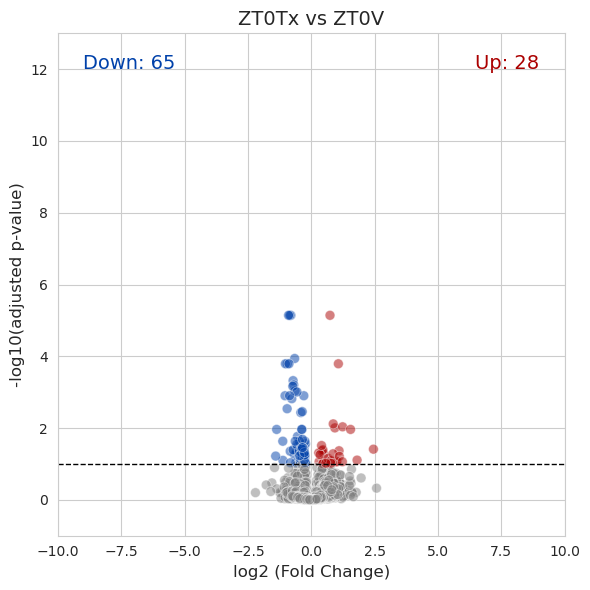

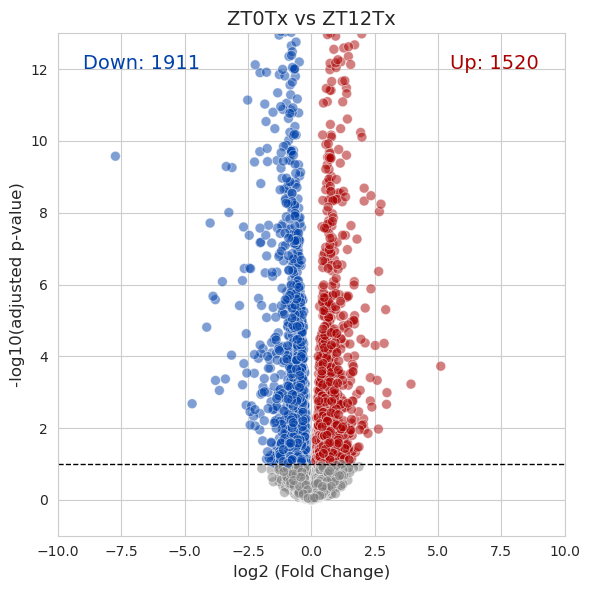

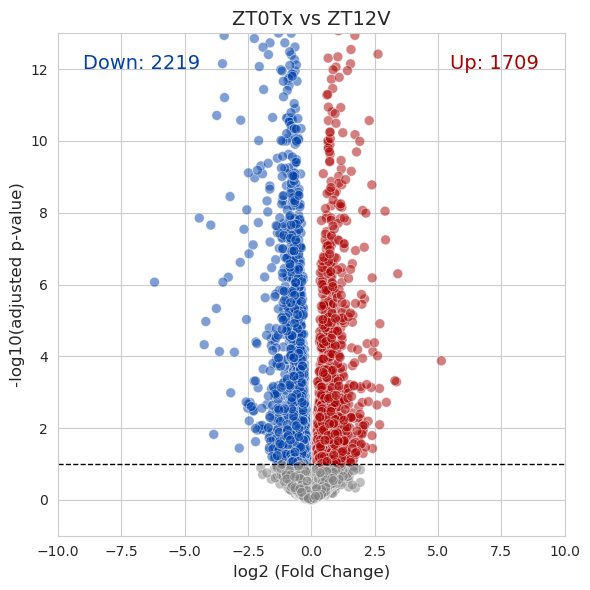

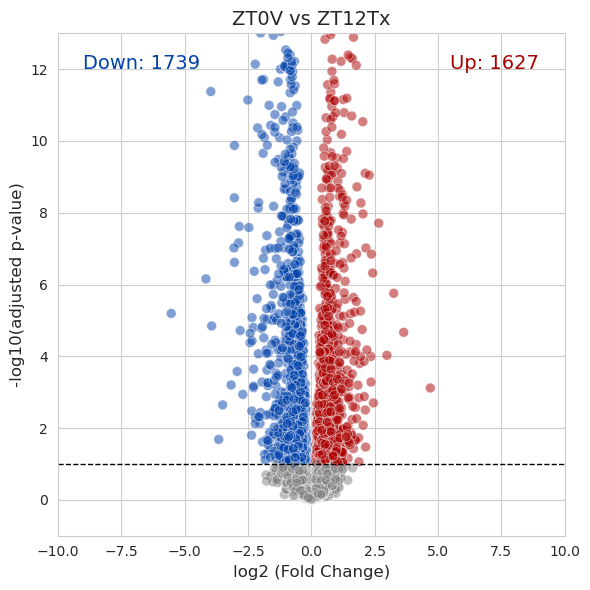

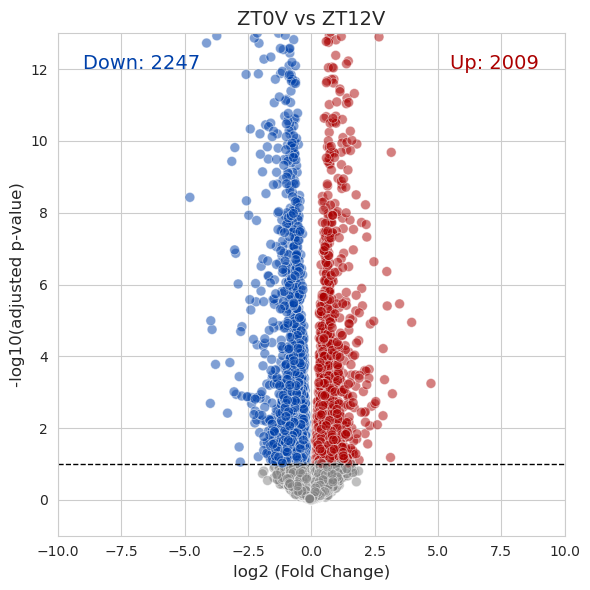

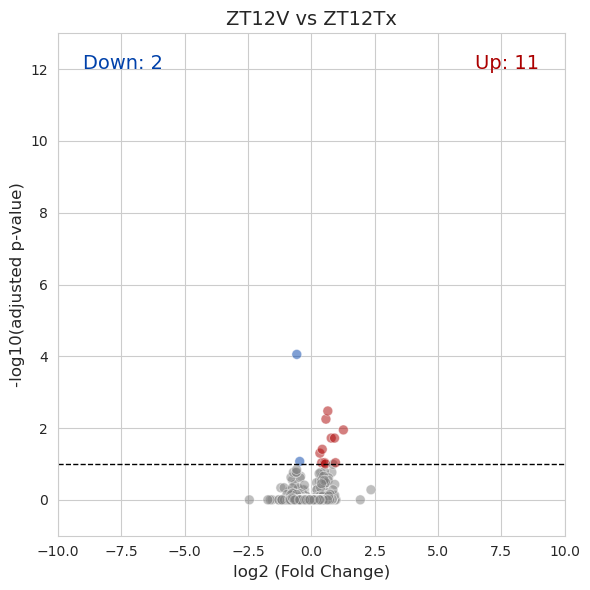

In [ ]:
palette = {
    "Up": "#ab0000",      # red 
    "Down": "#0041aa",    # blue
    "Unchange": "gray"
}

def volcano_plot(df, title):

    plt.figure(figsize=(6,6))
    with sns.axes_style("whitegrid"):
        sns.scatterplot(
            data=df, 
            x="log2FoldChange", 
            y= "-log10(padj)", 
            hue="regulation",
            palette=palette,
            s=50,
            alpha=0.5,
            legend=None
        )

    # Cutoff lines
    plt.axhline(1, color="black", linestyle="--", linewidth=1)

    # Count categories
    up_count = (df["regulation"] == "Up").sum()
    down_count = (df["regulation"] == "Down").sum()

    plt.text(-9, 12, f"Down: {down_count}", fontsize=14, color='#0041aa', ha='left' )
    plt.text(9, 12, f"Up: {up_count}", fontsize=14, color='#ab0000', ha='right')

    # Labels
    plt.xlabel("log2 (Fold Change)", fontsize=12)
    plt.ylabel("-log10(adjusted p-value)", fontsize=12)
    plt.title(title, fontsize=14)
    plt.xlim(-10,10)
    plt.ylim(-1,13)

    plt.tight_layout()
    plt.show()


for name, df in data_sets.items():
    volcano_plot(df, name)


## Ontologies

def annotations(df):
    queries ={'ensembl_gene_id': list(df[df["regulation"] != "Unchange"].index) } 
    results = bm.query(dataset='mmusculus_gene_ensembl',
                   attributes=['ensembl_gene_id', 'external_gene_name', 'entrezgene_id', 'go_id'],
                   filters=queries)
    df = pd.merge(df, results, left_index=True, right_on='ensembl_gene_id', how='left')

    return df

for name, df in data_sets.items():
    data_sets[name] = annotations(df)

In [ ]:
# querring M. musculus anotated genes

#dataset = Dataset(name='mmusculus_gene_ensembl', host='http://www.ensembl.org')

#results = dataset.query(attributes=[
#    'ensembl_gene_id',
#    'external_gene_name',
#    'entrezgene_id',
#    'go_id'
#])
#results.to_csv("/home/cvillazon/results/mmusculus_genename_go.csv", index=False, columns=True)
#results
#results.to_csv("/home/cvillazon/results/mmusculus_genename_go.csv", index=False, columns=["Gene stable ID","Gene name", "GO term accession"])
mmus_genes = pd.read_csv("/home/cvillazon/results/mmusculus_genename_go.csv", header=0)

In [ ]:
gene_map = (
    mmus_genes
    .drop_duplicates(subset="Gene stable ID")
    .set_index("Gene stable ID")["Gene name"])

for name, df in data_sets.items():
    df["Gene name"] = df.index.map(gene_map)
    

In [7]:
gene_map

Gene stable ID
ENSMUSG00000064336            mt-Tf
ENSMUSG00000064337          mt-Rnr1
ENSMUSG00000064338            mt-Tv
ENSMUSG00000064339          mt-Rnr2
ENSMUSG00000064340           mt-Tl1
                          ...      
ENSMUSG00000026835             Fcnb
ENSMUSG00000085693          Gm13371
ENSMUSG00000086425    F730016J06Rik
ENSMUSG00000128341          Gm74850
ENSMUSG00000026833            Olfm1
Name: Gene name, Length: 78334, dtype: str

In [ ]:
background = pd.concat([df["Gene name"] for _,df in data_sets.items()])

background = background[~background.duplicated()]
#background.to_csv("/home/cvillazon/results/m_background.csv", columns=["Gene name"])
background_lst = [str(gene).upper() for gene in background]

In [21]:
def enrichment_analysis(df, title, gene_set):

    gene_list = list((df[df["regulation"] != "Unchange"]["Gene name"]).dropna())
    gene_list = [str(gene).upper() for gene in gene_list]

    try:
        enr = gp.enrichr(gene_list=gene_list,
                        gene_sets=gene_set, #WikiPathways_2024_Mouse GO_Biological_Process_2025
                        organism='mouse', 
                        background=background_lst,
                        outdir=None, # don't write to disk
                        )
        
        enr.results = enr.results[enr.results["Adjusted P-value"] < 0.05]
        return enr

    except (IndexError, KeyError, AttributeError, TypeError):
        print(f"Skipping {title}")
        return None

enr_res = {name: [] for name in data_sets.keys()}
for name, df in data_sets.items():
    enr_res[name].append(enrichment_analysis(df, name, ['WikiPathways_2024_Mouse']))
    enr_res[name].append(enrichment_analysis(df, name, ['GO_Biological_Process_2025']))

In [22]:
for name in enr_res.keys():
    print(name)
    try:
        print(f'{len(list(enr_res[name][0].results["Term"]))}, {len(list(enr_res[name][1].results["Term"]))}')
    except (IndexError, KeyError, AttributeError, TypeError):
        print(f"Skipping {name}")

ZT0Tx-ZT12Tx
71, 417
ZT0V-ZT0Tx
10, 42
ZT0V-ZT12Tx
69, 360
ZT0V-ZT12V
54, 351
ZT12V-ZT0Tx
69, 460
ZT12V-ZT12Tx
0, 45


In [23]:
gos_sets = []
wiki_sets = []

for name, df in enr_res.items():
    try:
        wiki_sets.append(set(df[0].results['Term']))
        gos_sets.append(set(df[1].results['Term']))
    except (IndexError, KeyError, AttributeError, TypeError):
        print(f"Skipping {name}")

gos = list(set().union(*gos_sets))
wiki = list(set().union(*wiki_sets))


print(f"GO terms: {len(gos)}")
print(f"Wiki terms: {len(wiki)}")

GO terms: 779
Wiki terms: 104


In [11]:
wiki

['TGF Beta Signaling Pathway WP113',
 'Spinal Cord Injury WP2432',
 'Parkinson 39 S Disease WP3638',
 'mRNA Processing WP310',
 'Fatty Acid Omega Oxidation WP33',
 'Focal Adhesion WP85',
 'Mapk Signaling Pathway WP493',
 'Electron Transport Chain WP295',
 'Factors And Pathways Affecting IGF1 Akt Signaling WP3675',
 'Selenium Metabolism Selenoproteins WP108',
 'Estrogen Metabolism WP1264',
 'Iron Homeostasis WP1596',
 'Kennedy Pathway WP1771',
 'IL 3 Signaling Pathway WP373',
 'Nuclear Receptors WP509',
 'Omega 3 Omega 6 Fatty Acid Synthesis WP4350',
 'Glycerolipids And Glycerophospholipids WP4345',
 'ID Signaling Pathway WP512',
 'Dysregulated miRNA Targeting In Insulin PI3K AKT Signaling WP3855',
 'Apoptosis WP1254',
 'Insulin Signaling WP65',
 'Lung Fibrosis WP3632',
 'Heart Development WP2067',
 'Glutathione And One Carbon Metabolism WP730',
 'Splicing Factor NOVA Regulated Synaptic Proteins WP1983',
 'Triacylglyceride Synthesis WP386',
 'Fatty Acid Beta Oxidation WP1269',
 'One Car

In [24]:
# Filter for relevant terms with regular expressions

pattern = r'lipid|insulin|glucose|cholesterol|sterol|bile|circadian|nuclear|adipo|estrogen'

relevant_gos = []
for go in gos:
    if re.search(pattern, go, re.IGNORECASE):
        relevant_gos.append(go)

relevant_wiki = []
for wik in wiki:
    if re.search(pattern, wik, re.IGNORECASE):
        relevant_wiki.append(wik)

relevant_gos


['Response to Insulin (GO:0032868)',
 'Bile Acid and Bile Salt Transport (GO:0015721)',
 'Negative Regulation of Insulin Secretion (GO:0046676)',
 'Phospholipid Transport (GO:0015914)',
 'Regulation of Lipid Biosynthetic Process (GO:0046890)',
 'Cholesterol Metabolic Process (GO:0008203)',
 'Regulation of Nuclear Receptor-Mediated Glucocorticoid Signaling Pathway (GO:2000322)',
 'Regulation of Lipid Catabolic Process (GO:0050994)',
 'Female Meiotic Nuclear Division (GO:0007143)',
 'Cellular Response to Glucose Starvation (GO:0042149)',
 'Positive Regulation of Lipid Storage (GO:0010884)',
 'Regulation of Glucose Metabolic Process (GO:0010906)',
 'Membrane Lipid Biosynthetic Process (GO:0046467)',
 'Positive Regulation of Lipid Biosynthetic Process (GO:0046889)',
 'Bile Acid Metabolic Process (GO:0008206)',
 'Phospholipid Catabolic Process (GO:0009395)',
 'Regulation of Cholesterol Biosynthetic Process (GO:0045540)',
 'Cellular Response to Glucose Stimulus (GO:0071333)',
 'Lipid Catabol

In [25]:
len(relevant_gos)

71

In [26]:
len(relevant_wiki)

13

### Ontology plots

In [16]:
# Code from Luis Tenorio 

def plot_ontologies(df, title, g_set):
    
    df['-log₁₀ (adjusted p-value)'] = df['Adjusted P-value'].apply(lambda x: -np.log10(x) if pd.notnull(x) and x > 0 else np.nan)
    df['log₂ (Odds Ratio)'] = df['Odds Ratio'].apply(lambda x: np.log2(x) if pd.notnull(x) and x > 0 else np.nan)
    df['Genes count'] = df['Genes'].apply(lambda x: len(x.split(';')) if pd.notnull(x) else 0)
    df = df.sort_values(by='log₂ (Odds Ratio)', ascending=False)
    df = df.head(20)  # Keep only top 20 terms for better visualization
    
    fig, ax = plt.subplots(figsize=(4, 7))

    # --- Scatter ---
    scatter = sns.scatterplot(
        data=df,
        x='log₂ (Odds Ratio)',
        y='Term',
        size='Genes count',
        sizes=(25, 180),
        hue='-log₁₀ (adjusted p-value)',
        palette='magma_r',
        edgecolor='k',
        alpha=0.85,
        legend='brief',
        ax=ax
    )

    # ----------------------------
    # Keep ONLY size legend (upper right)
    # ----------------------------
    handles, labels = ax.get_legend_handles_labels()
    size_start = labels.index('Genes count')

    size_legend = ax.legend(
        handles[size_start:],
        labels[size_start:],
        bbox_to_anchor=(1, 1),
        loc='upper left',
        frameon=False
    )

    # ----------------------------
    # Create smaller colorbar axis
    # ----------------------------
    norm = mpl.colors.Normalize(
        vmin=df['-log₁₀ (adjusted p-value)'].min(),
        vmax=df['-log₁₀ (adjusted p-value)'].max()
    )

    sm = mpl.cm.ScalarMappable(
        cmap='magma_r',
        norm=norm
    )
    sm.set_array([])

    # Manually position colorbar (right lower corner)
    cax = fig.add_axes([0.88, 0.15, 0.03, 0.3])
    # [left, bottom, width, height]  → tweak if needed

    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label('-log₁₀ (adjusted p-value)')

    # ----------------------------
    # Layout tweaks
    # ----------------------------
    ax.set_ylabel(None)
    ax.set_title("{} - {}".format(title, g_set), fontsize=12)

    plt.subplots_adjust(right=0.8)  # Make space for legends

/tmp/ipykernel_2391615/2130901833.py:14: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  scatter = sns.scatterplot(


Skipping ZT12V vs ZT12Tx


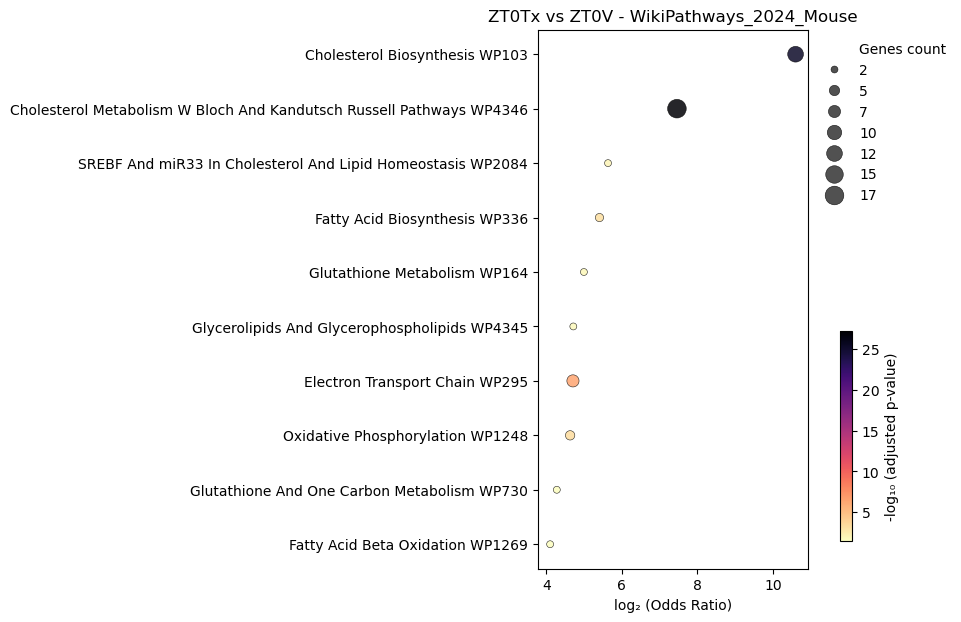

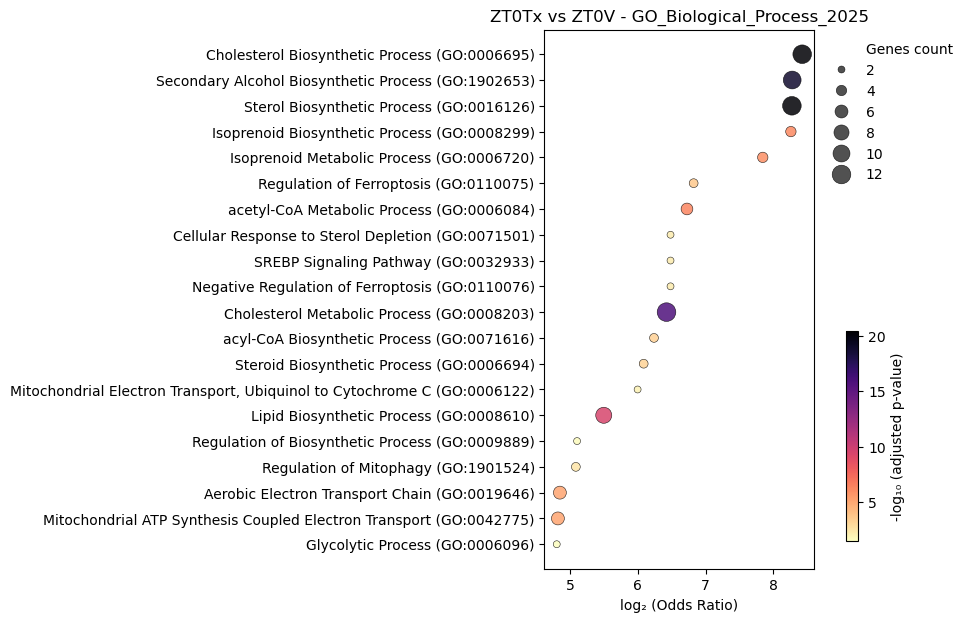

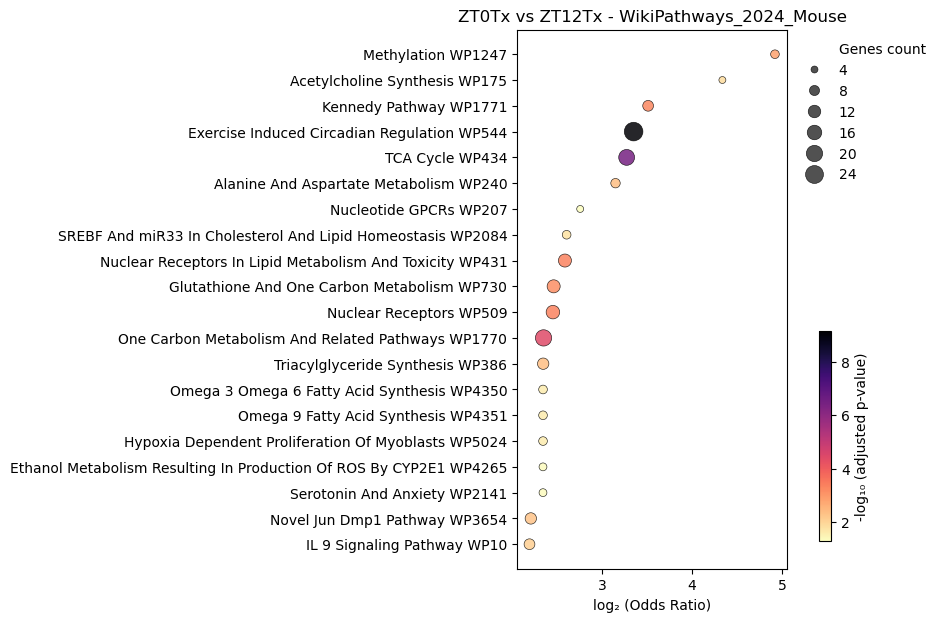

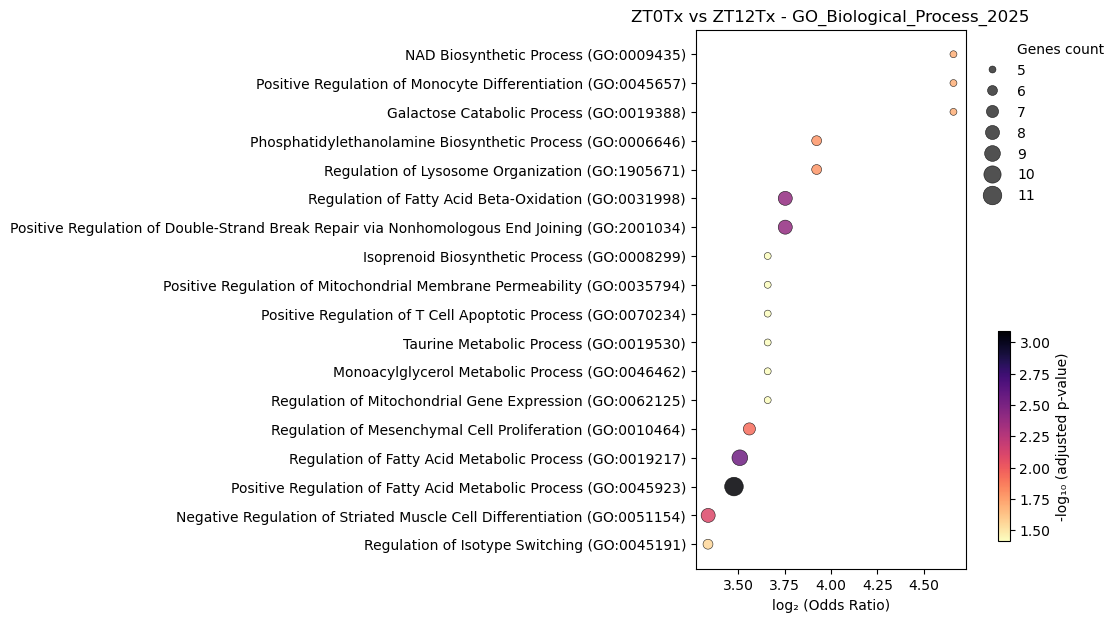

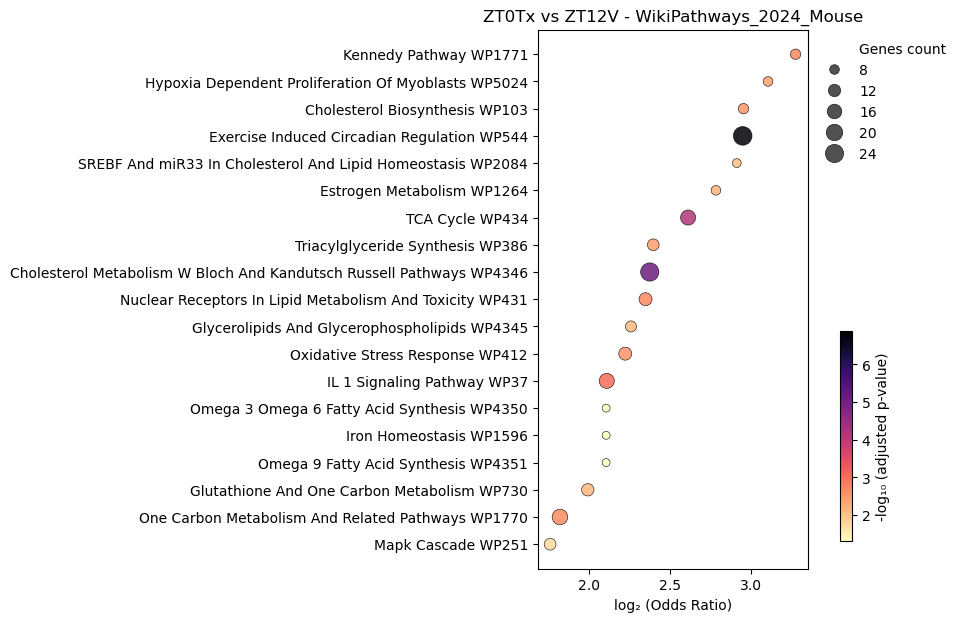

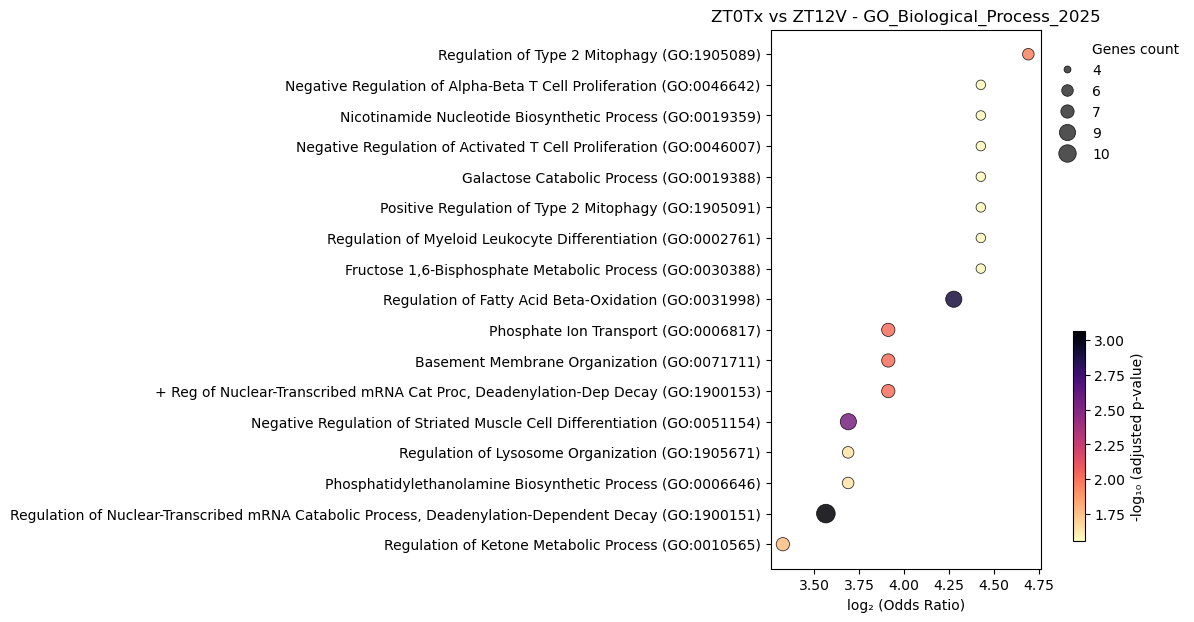

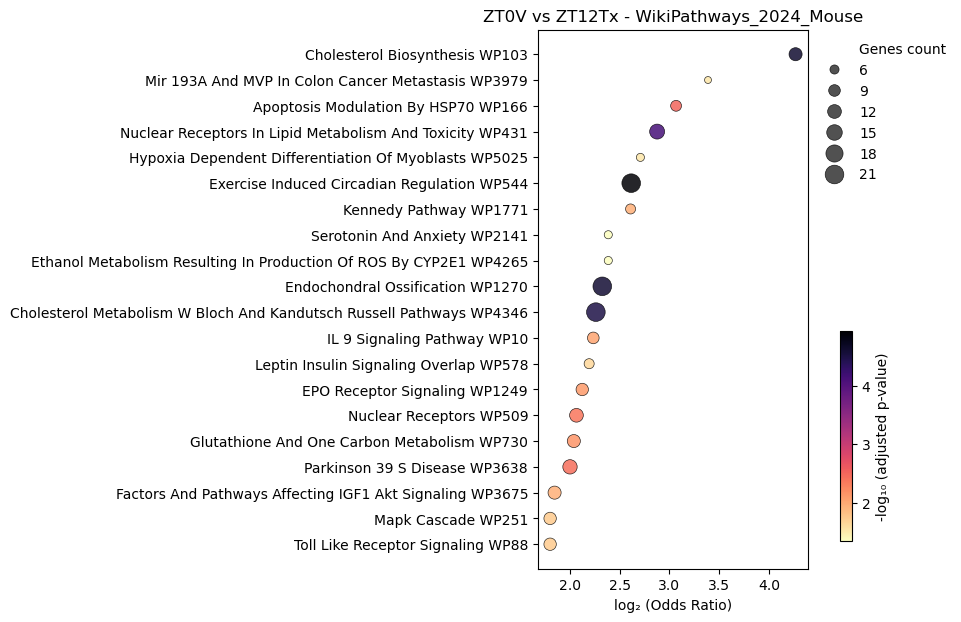

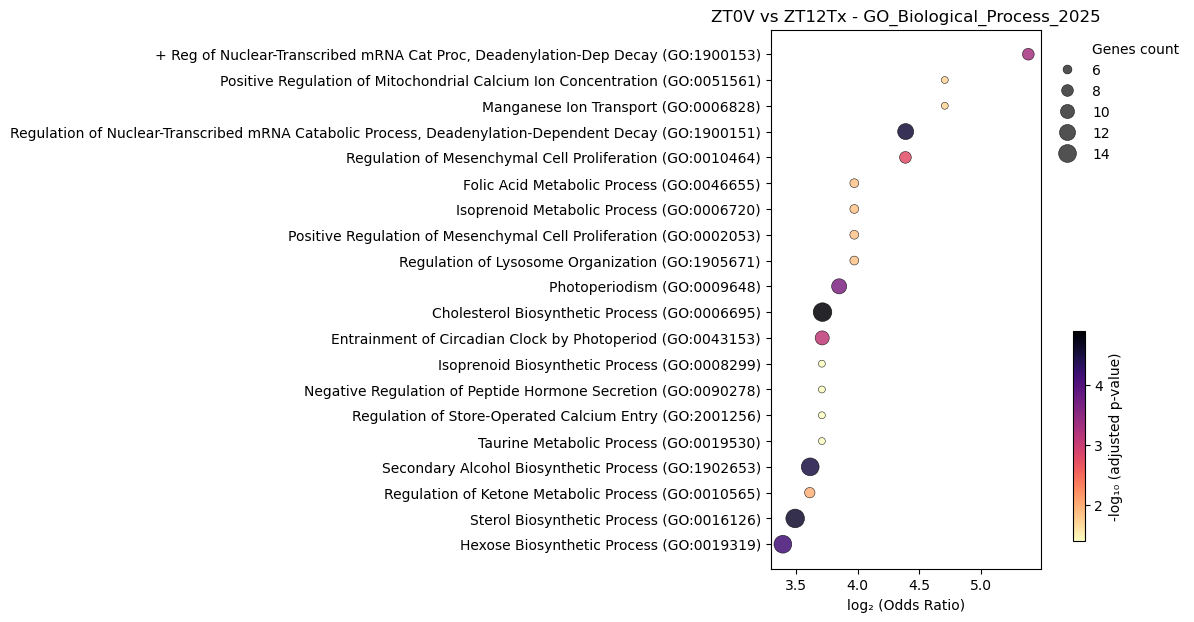

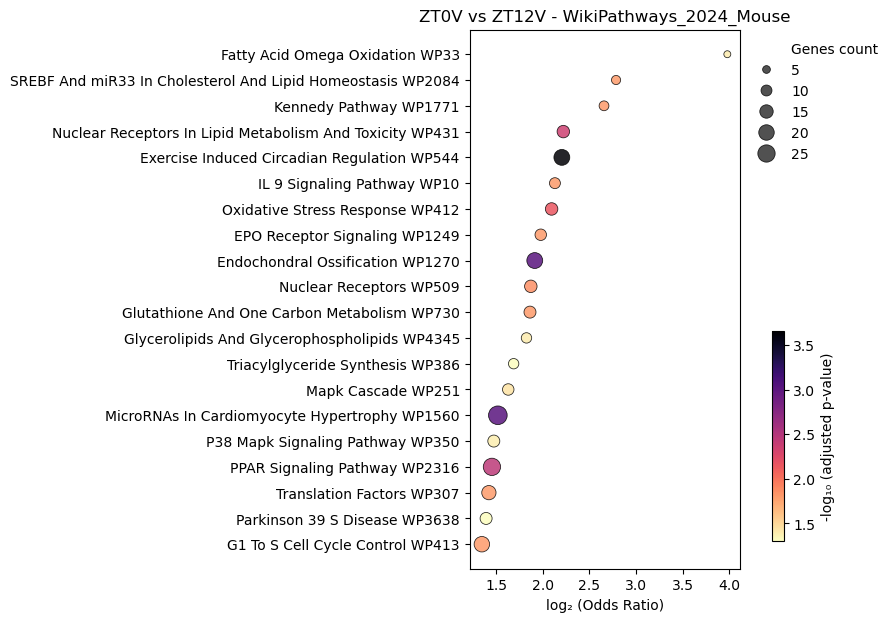

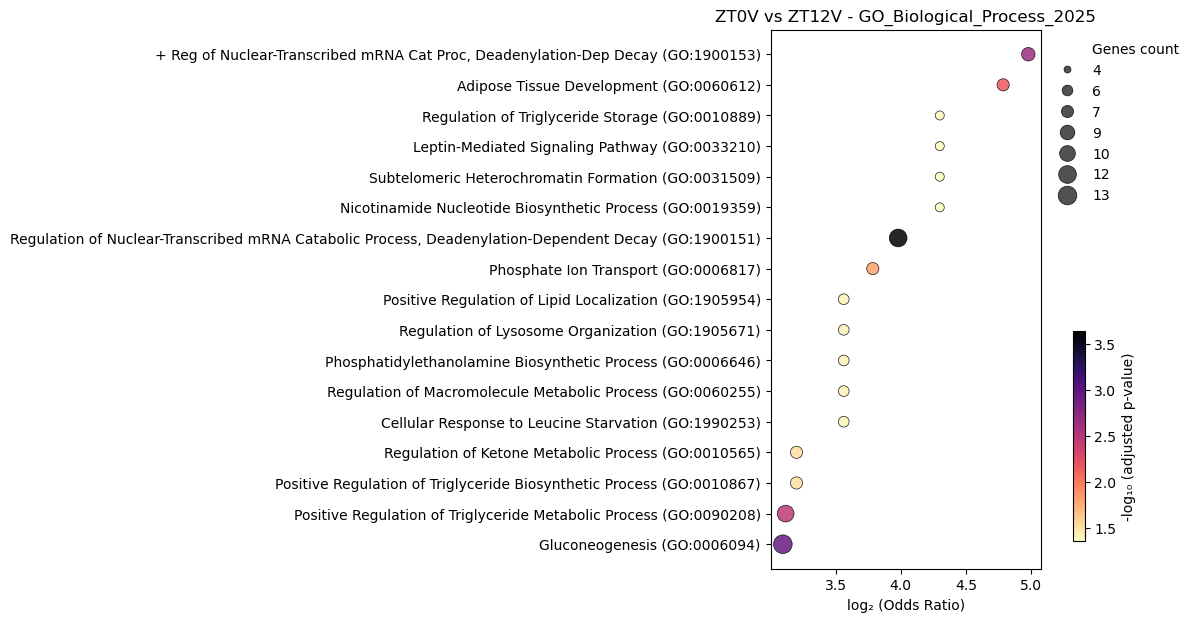

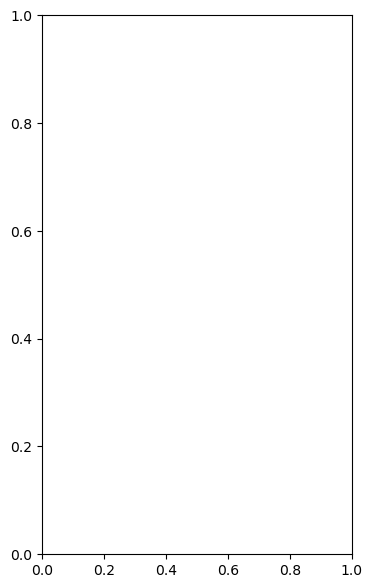

In [17]:
for name, df in enr_res.items():
    try:
        plot_ontologies(df[0].results, name, 'WikiPathways_2024_Mouse')
        plot_ontologies(df[1].results, name, 'GO_Biological_Process_2025')
    except (IndexError, KeyError, AttributeError, TypeError, ValueError):
        print(f"Skipping {name}")

## GSVA

In [18]:
pw_genes = pd.DataFrame(columns=['ensembl_gene_id', 'external_gene_name'])

for _, df in data_sets.items():
    pw_genes = pd.concat([pw_genes, df[df["regulation"] != "Unchange"][['ensembl_gene_id', 'external_gene_name']].drop_duplicates()])

pw_genes.head()

,ensembl_gene_id,external_gene_name
0.0,ENSMUSG00000000301,Pemt
20.0,ENSMUSG00000001467,Cyp51
47.0,ENSMUSG00000003528,Slc25a1
58.0,ENSMUSG00000006057,Atp5mc1
73.0,ENSMUSG00000006517,Mvd


In [ ]:
# Prepare data for GSVA

# Load counts for later use in enrichment analysis with GSEApy

counts = pd.read_csv('/home/cvillazon/results/mRNA_SNAKEPipes_out/featureCounts/counts_male.tsv', sep='\t', header=0)

counts = counts[['gene', 'ZT0Tx_Rep2','ZT0Tx_Rep3','ZT0Tx_Rep4','ZT0V_Rep2',
                 'ZT0V_Rep3','ZT0V_Rep4','ZT12Tx_Rep2','ZT12Tx_Rep3',
                 'ZT12Tx_Rep4','ZT12V_Rep2','ZT12V_Rep3','ZT12V_Rep4'
                    ]].set_index('gene')

ZTs_counts = counts.loc[counts.index.isin(list(pw_genes['ensembl_gene_id']))]

ZTs_counts = pd.merge(left=ZTs_counts, right=pw_genes, left_index=True, right_on='ensembl_gene_id', how='left')

ZTs_counts = ZTs_counts.drop(columns=["ensembl_gene_id"])

ZTs_counts = ZTs_counts.rename(columns={"external_gene_name": "gene", 'ZT0Tx_Rep2':'ZT0_Tx_Rep2','ZT0Tx_Rep3':'ZT0_Tx_Rep3','ZT0Tx_Rep4':'ZT0_Tx_Rep4','ZT0V_Rep2':'ZT0_V_Rep2',
                 'ZT0V_Rep3':'ZT0_V_Rep3','ZT0V_Rep4':'ZT0_V_Rep4','ZT12Tx_Rep2':'ZT12_Tx_Rep2','ZT12Tx_Rep3':'ZT12_Tx_Rep3',
                 'ZT12Tx_Rep4':'ZT12_Tx_Rep4','ZT12V_Rep2':'ZT12_V_Rep2','ZT12V_Rep3':'ZT12_V_Rep3','ZT12V_Rep4':'ZT12_V_Rep4'})

ZTs_counts["gene"] = ZTs_counts["gene"].str.upper()

ZTs_counts = ZTs_counts.set_index('gene')

##Filter expressed genes 
### Keep only genes with counts > 10 in at least 50% of samples
threshold = 10
fraction = 0.5

ZTs_exp_counts  = ZTs_counts[
        (ZTs_counts.iloc[:, 1:] > threshold).sum(axis=1) >= fraction * (ZTs_counts.shape[1] - 1)
    ]

# Step 1: Calculate geometric mean per gene
geom_means = ZTs_exp_counts.apply(lambda x: np.exp(np.log(x.replace(0, np.nan)).mean()), axis=1)
    
# Step 2: Compute size factors (median ratio per sample)
size_factors = ZTs_exp_counts.div(geom_means, axis=0).median(axis=0)
    
# Step 3: Normalize counts
norm_exp_df = ZTs_exp_counts.div(size_factors, axis=1)

normalized_counts = norm_exp_df.reset_index()


def reshape_gene_counts(df):
    # Melt the dataframe to long format
    tidy_df = df.melt(id_vars='gene', var_name='Experiment', value_name='Normalized Counts')

    # Extract Diet, Circadian time and rep
    tidy_df[['Circadian Time', 'Treatment','rep']] = tidy_df['Experiment'].str.split('_', expand=True)

    # Combine both treatment and Circadian Time for a condition
    tidy_df['Condition'] = tidy_df['Treatment'] + ' ' + tidy_df['Circadian Time']

    # Replace Experiment to be space sepatared for visualizing purposes
    tidy_df['Experiment'] = tidy_df['Condition'] + " " + tidy_df['rep']
    

    return tidy_df

tidy_counts = reshape_gene_counts(normalized_counts)

genes_cond_pivot = pd.pivot_table(tidy_counts, index='gene', columns='Condition', 
                              values='Normalized Counts')
genes_cond_pivot = genes_cond_pivot.dropna()

genes_cond_upper_pivot = genes_cond_pivot.copy()

genes_cond_upper_pivot.index = genes_cond_pivot.index.str.upper()




In [20]:
genes_cond_upper_pivot.head()

Condition,Tx ZT0,Tx ZT12,V ZT0,V ZT12
gene,,,,
0610005C13RIK,2164.497056,2614.096017,2027.121938,2927.335158
0610030E20RIK,933.280575,463.704550,866.576633,431.153672
0610031O16RIK,476.182102,383.220623,405.968608,477.375296
0610043K17RIK,29.809718,67.480781,40.789716,75.083765
1110019D14RIK,55.222156,47.484250,54.491388,29.823697


In [21]:
# extracting genes and pathways
pathway_gene_sets_GO = {}

for name, df in enr_res.items():
    for _, row in df[1].results.iterrows():
        pathway = row["Term"]
        genes = [
            g.strip().upper()
            for g in str(row["Genes"]).split(";")
            if g.strip()
        ]
        pathway_gene_sets_GO[pathway] = genes

pathway_gene_sets_Wiki = {}
for name, df in enr_res.items():
    for _, row in df[0].results.iterrows():
        pathway = row["Term"]
        genes = [
            g.strip().upper()
            for g in str(row["Genes"]).split(";")
            if g.strip()
        ]
        pathway_gene_sets_Wiki[pathway] = genes

In [22]:
expr_genes = set(str(gene).upper() for gene in pw_genes["external_gene_name"])

pathway_gene_sets_GO = {
    pw: list(set(genes) & expr_genes)
    for pw, genes in pathway_gene_sets_GO.items()
    if len(set(genes) & expr_genes) >= 5  # minimum size
}

pathway_gene_sets_Wiki = {
    pw: list(set(genes) & expr_genes)
    for pw, genes in pathway_gene_sets_Wiki.items()
    if len(set(genes) & expr_genes) >= 5  # minimum size
}

In [23]:
pathway_gene_sets_GO = {key: value for key, value in pathway_gene_sets_GO.items() if key in relevant_gos}

pathway_gene_sets_Wiki = {key: value for key, value in pathway_gene_sets_Wiki.items() if key in relevant_wiki}

print(f"GO pathways: {len(pathway_gene_sets_GO)}")
print(f"Wiki pathways: {len(pathway_gene_sets_Wiki)}")

GO pathways: 50
Wiki pathways: 13


In [24]:
import json
with open('pathway_gene_sets_GO.json', 'w') as fout:
    json.dump(pathway_gene_sets_GO, fout)

with open('pathway_gene_sets_Wiki.json', 'w') as fout:
    json.dump(pathway_gene_sets_Wiki, fout)

In [25]:
expr_gsva = genes_cond_pivot.copy()
expr_gsva = expr_gsva[~expr_gsva.index.duplicated()] # ~ boolean negation
expr_gsva = expr_gsva.dropna()
expr_gsva.index = expr_gsva.index.astype(str)
expr_gsva.index.name = None
expr_gsva.columns.name = None

expr_for_gsva = expr_gsva.copy()

# force gene names (now columns) to string
expr_for_gsva.columns = expr_for_gsva.columns.astype(str)

expr_for_gsva.columns = (
    expr_for_gsva.columns
    .map(str)
    .str.replace(r"\.0$", "", regex=True)
)

expr_for_gsva = pd.DataFrame(
    expr_for_gsva.values,
    index=expr_for_gsva.index.astype(str),
    columns=expr_for_gsva.columns.astype(str),
)

In [26]:
expr_for_gsva.to_csv('expr_for_gsva.csv')

In [30]:
gsva_scores_Wiki = pd.read_csv("/home/cvillazon/DEseq2_males/gsva_es_wiki.csv", header=0, index_col=0)

gsva_scores_GO = pd.read_csv("/home/cvillazon/DEseq2_males/gsva_es_go.csv", header=0, index_col=0)

In [37]:
gsva_scores_Wiki

,Tx.ZT0,Tx.ZT12,V.ZT0,V.ZT12
Cholesterol Metabolism W Bloch And Kandutsch Russell Pathways WP4346,-0.481711,-0.438625,0.633730,0.235245
Cholesterol Biosynthesis WP103,-0.699216,-0.514117,0.788940,0.351094
SREBF And miR33 In Cholesterol And Lipid Homeostasis WP2084,-0.672909,0.266046,-0.464526,0.737391
Glycerolipids And Glycerophospholipids WP4345,-0.252464,0.171330,-0.151596,0.285337
Exercise Induced Circadian Regulation WP544,-0.173406,0.120652,-0.067892,0.132978
Adipogenesis Genes WP447,-0.232430,-0.093608,0.029203,0.258777
Insulin Signaling WP65,-0.245363,0.107698,-0.262846,0.375541
Nuclear Receptors WP509,-0.295021,0.070239,-0.163396,0.428670
Nuclear Receptors In Lipid Metabolism And Toxicity WP431,-0.227373,0.150110,-0.274299,0.547856
Estrogen Signaling WP1244,-0.034577,0.115973,-0.094644,0.075418


In [32]:
heatmap_df_GO = gsva_scores_GO

condition_order = ["Tx.ZT0", "Tx.ZT12", "V.ZT0", "V.ZT12"]

heatmap_df_GO = heatmap_df_GO[condition_order]

heatmap_df_GO = heatmap_df_GO.fillna(0)

In [33]:
# Define the colors
colors = ['#0041aa','#fefefe','#ab0000']

# Create the colormap
custom_cmap = mcolors.LinearSegmentedColormap.from_list('custom_gradient', colors)

/home/seisbio/miniforge/lib/python3.12/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


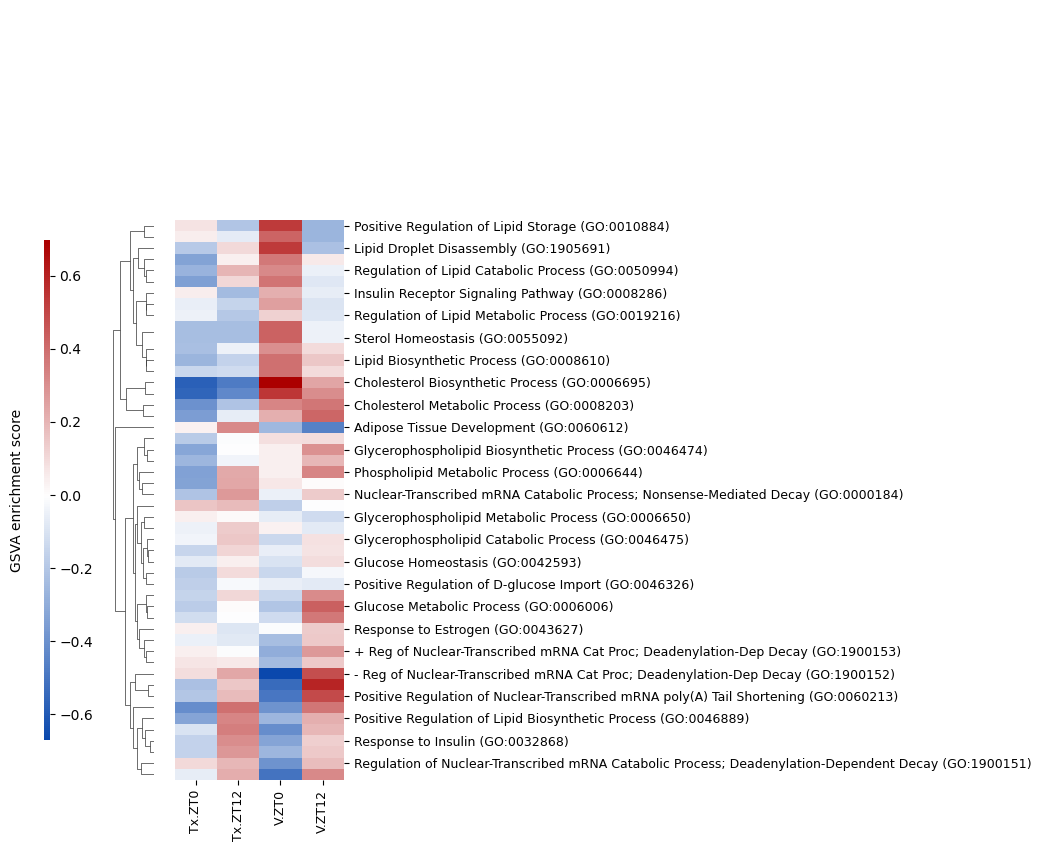

In [34]:
g = sns.clustermap(
    heatmap_df_GO,
    cmap=custom_cmap,
    center=0,
    #linewidths=0.5,
    figsize=(3, 10),
    cbar_pos=(-0.1, 0.15, 0.02, 0.5),  # right-center
    col_cluster=False
)

# Rotate & resize x tick labels
plt.setp(
    g.ax_heatmap.get_xticklabels(),
    rotation=0,
    ha="center",
    fontsize=8
)

# Optional: resize y labels
plt.setp(
    g.ax_heatmap.get_yticklabels(),
    fontsize=9
)

# Optional: colorbar label
g.cax.set_ylabel(
    "GSVA enrichment score",
    rotation=90,
    labelpad=-60
)

g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_xticklabels(
    heatmap_df_GO.columns,
    rotation=90,
    #ha="center",
    fontsize=9
)
g.ax_heatmap.set_ylabel("")
plt.savefig('GSVA_cluster_go.pdf', bbox_inches='tight')
plt.show()

In [35]:
heatmap_df_Wiki = gsva_scores_Wiki

condition_order = ["Tx.ZT0", "Tx.ZT12", "V.ZT0", "V.ZT12"]

heatmap_df_Wiki = heatmap_df_Wiki[condition_order]

heatmap_df_Wiki = heatmap_df_Wiki.fillna(0)

/home/seisbio/miniforge/lib/python3.12/site-packages/seaborn/matrix.py:1113: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  self._figure.tight_layout(**tight_params)


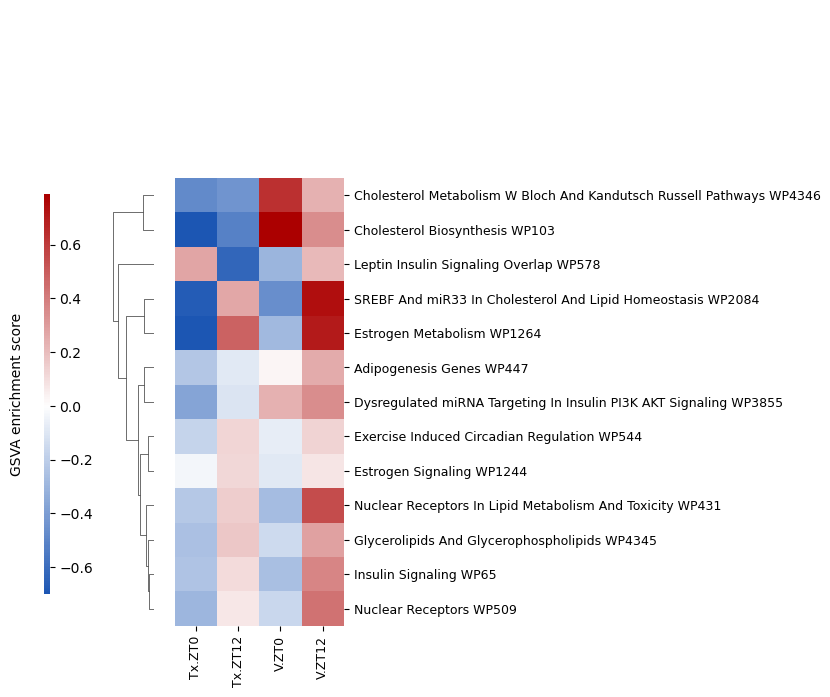

In [36]:
g = sns.clustermap(
    heatmap_df_Wiki,
    cmap=custom_cmap,
    center=0,
    #linewidths=0.5,
    figsize=(3, 8),
    cbar_pos=(-0.1, 0.15, 0.02, 0.5),  # right-center
    col_cluster=False
)

# Rotate & resize x tick labels
plt.setp(
    g.ax_heatmap.get_xticklabels(),
    rotation=0,
    ha="center",
    fontsize=8
)

# Optional: resize y labels
plt.setp(
    g.ax_heatmap.get_yticklabels(),
    fontsize=9
)

# Optional: colorbar label
g.cax.set_ylabel(
    "GSVA enrichment score",
    rotation=90,
    labelpad=-60
)

g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_xticklabels(
    heatmap_df_Wiki.columns,
    rotation=90,
    #ha="center",
    fontsize=9
)
g.ax_heatmap.set_ylabel("")
plt.savefig('GSVA_cluster_wiki.pdf', bbox_inches='tight')
plt.show()